# Online Purchase Prediction System

## Introduction & Problem Statement

With the rapid growth of e-commerce platforms, understanding customer behavior has become a critical challenge for online businesses. Every day, thousands of users browse online stores, but only a small percentage actually complete a purchase. Being able to identify which visitors are likely to buy a product can significantly improve business decision-making, marketing strategies, and conversion rates.

This project aims to build a machine learning system that predicts whether a user session will result in a purchase. The prediction is based on behavioral data collected during a user's interaction with an e-commerce website, such as the number of pages visited, time spent on different sections of the site, bounce rates, and visitor type.

The problem is formulated as a **binary classification task**, where the model predicts one of two outcomes:

- **Revenue = TRUE:** The user completed a purchase  
- **Revenue = FALSE:** The user left the website without purchasing

By analyzing browsing patterns and session characteristics, the system learns to distinguish between purchasing and non-purchasing sessions. Such predictions can help businesses target high-intent customers more effectively and optimize marketing resources.

## Dataset Selection & Justification

To address the purchase prediction problem, we selected the **Online Shoppers Intention Dataset**, which contains real browsing session data collected from an e-commerce website over a one-year period. This dataset captures detailed behavioral information about user interactions, making it highly suitable for analyzing online purchasing behavior.

The dataset includes both numerical and categorical features that describe user engagement during a browsing session. These features allow machine learning models to identify patterns associated with purchase decisions.

- **Dataset Title:** Online Shoppers Intention Dataset (UCI Machine Learning Repository)
- **Source (Kaggle URL):**
  https://www.kaggle.com/datasets/henrysue/online-shoppers-intention
- **Dataset Type:** Structured tabular dataset (session-level records)
- **Size:** 12,330 user sessions
- **Features:** 18 attributes describing browsing behavior and session characteristics, including:
  - number of pages visited and time spent on different page categories,
  - bounce rate and exit rate,
  - visitor type and month,
  - other session-level attributes.
- **Target Variable:** `Revenue`
  - Binary label indicating whether the session resulted in a purchase (**TRUE**) or not (**FALSE**).

### Why this dataset?
- It directly matches the project goal: predicting purchase completion using session behavior.
- It is a real-world e-commerce dataset, making results meaningful and applicable.
- It contains a mix of **numerical and categorical** features, enabling comprehensive preprocessing and model comparison.
- It satisfies the project requirements:
  - Structured tabular dataset
  - Multiple features (≥ 10)
  - Large number of observations (thousands)
  - Binary classification target

### License Information
- Kaggle License: **Other (specified in description)** (as stated on the Kaggle dataset page).
- Original source: UCI Machine Learning Repository  
  https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset


## Initial Data Inspection

Before performing deeper analysis, we begin by inspecting the dataset structure. This step helps us understand the size of the dataset, the types of features available, and whether there are any missing values.

The following checks are performed:

- Viewing the first few rows of the dataset
- Examining the dataset dimensions
- Inspecting data types of each feature
- Checking for missing values

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/kaggle/raw_kaggle_data.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
df.shape

(12330, 18)

The dataset contains 12,330 observations (rows) and 18 features (columns).
Each row represents a unique user session, and each column represents a session-related attribute.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

The `df.info()` output provides a detailed structural summary of the dataset.

It confirms that the dataset contains 12,330 entries across 18 columns.
All columns have 12,330 non-null values, which indicates that there are no missing values in the dataset.

The dataset includes multiple data types:
- Integer features (int64)
- Floating-point features (float64)
- Categorical features (object)
- Boolean features (bool)

The presence of categorical and boolean variables (e.g., Month, VisitorType, Weekend, Revenue) suggests that encoding techniques will be required during the preprocessing stage before applying machine learning models.

Overall, the dataset is structurally complete and suitable for further exploratory data analysis.

In [ ]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


### Missing Values Analysis

To ensure data quality, a missing values check was performed using `df.isnull().sum()`.

The results indicate that all features contain zero missing values.

This confirms that the dataset is complete and does not require any imputation or missing-value handling before preprocessing.

In [ ]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


### Descriptive Statistics Analysis

The `df.describe()` output provides summary statistics for the numerical features in the dataset.

It summarizes the following statistical measures:
- Count of observations
- Mean values
- Standard deviation
- Minimum and maximum values
- Quartile distribution (25%, 50%, 75%)

From the statistical summary, we observe that:

- Duration-related features (e.g., Administrative_Duration and ProductRelated_Duration) show wide value ranges, indicating variability in user browsing time across sessions.
- BounceRates and ExitRates are small decimal values representing session-level proportions.
- Some numerical features exhibit skewed distributions due to the presence of extreme values.
- The variation in PageValues suggests differences in session engagement and purchase likelihood.

Overall, the descriptive statistics confirm that the dataset contains meaningful numerical variability and is suitable for further exploratory data analysis.

### Conclusion of Initial Inspection

The dataset has been successfully examined in terms of structure, completeness, and statistical properties.  
No missing values were detected, and the dataset contains a mixture of numerical, categorical, and boolean variables.

The data is structurally clean and ready for further **Exploratory Data Analysis (EDA)**, where we will investigate relationships between features and purchasing behavior through visualizations.


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a critical step in the machine learning pipeline used to understand underlying patterns, detect anomalies, and test hypotheses within the dataset. For this project, EDA focuses on identifying the key drivers of online purchase behavior.

The primary objectives of this EDA are:

1. **Data Health Assessment:** Identifying and handling missing values and duplicate records to ensure the model learns from high-quality and reliable data.

2. **Target Variable Analysis:** Examining the distribution of the `Revenue` column to identify potential class imbalance between buyers (True) and non-buyers (False).

3. **Feature Correlation:** Determining which session attributes—such as `PageValues`, `BounceRates`, and `ExitRates`—have the strongest statistical relationship with successful transactions.

4. **Behavioral and Seasonal Trends:** Analyzing how user purchase intent fluctuates based on temporal factors such as the `Month`.

###Dataset Overview

In [ ]:
#  Dataset Overview
print("Dimensions:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

Dimensions: (12330, 18)

Missing Values:
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


###Feature Analysis

In [ ]:
#  Feature Analysis
print("Unique Months:", df['Month'].unique())
print("Visitor Types:", df['VisitorType'].unique())

Unique Months: ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
Visitor Types: ['Returning_Visitor' 'New_Visitor' 'Other']


The dataset includes categorical features such as Month and VisitorType.
VisitorType distinguishes between returning visitors and new visitors, while Month captures seasonal behavior patterns.

###Visualization

1. Visualize the Target Variable (Revenue)
Since the goal is to predict purchases, we must see how many sessions actually resulted in revenue.

/tmp/ipykernel_496/478604529.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette='pastel')


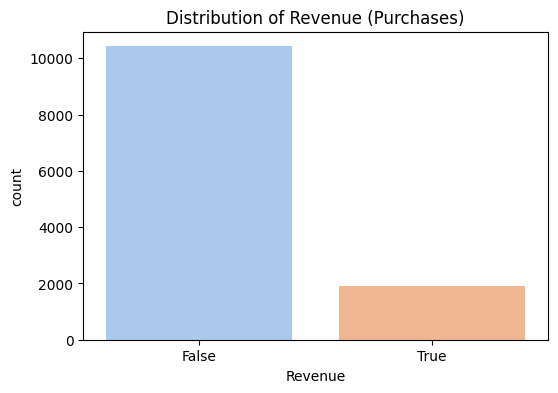

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the distribution of Revenue
plt.figure(figsize=(6, 4))
sns.countplot(x='Revenue', data=df, palette='pastel')
plt.title('Distribution of Revenue (Purchases)')
plt.show()

# Print the exact percentage of shoppers who bought something
print(df['Revenue'].value_counts(normalize=True) * 100)

2. Identify Key Behavioral Drivers
In e-commerce, certain behaviors are "gold mines" for prediction.PageValues (the average value of a web page visited) and ExitRates.

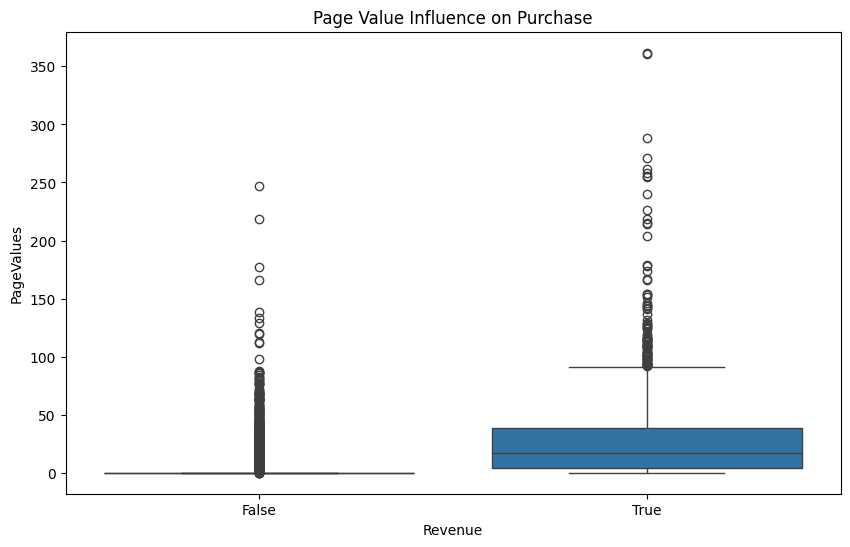

In [ ]:
# Boxplot for PageValues vs Revenue
plt.figure(figsize=(10, 6))
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.title('Page Value Influence on Purchase')
plt.show()

3. Check for Feature Correlations
A heatmap will show  which features are redundant and which are strongly linked to the final purchase.

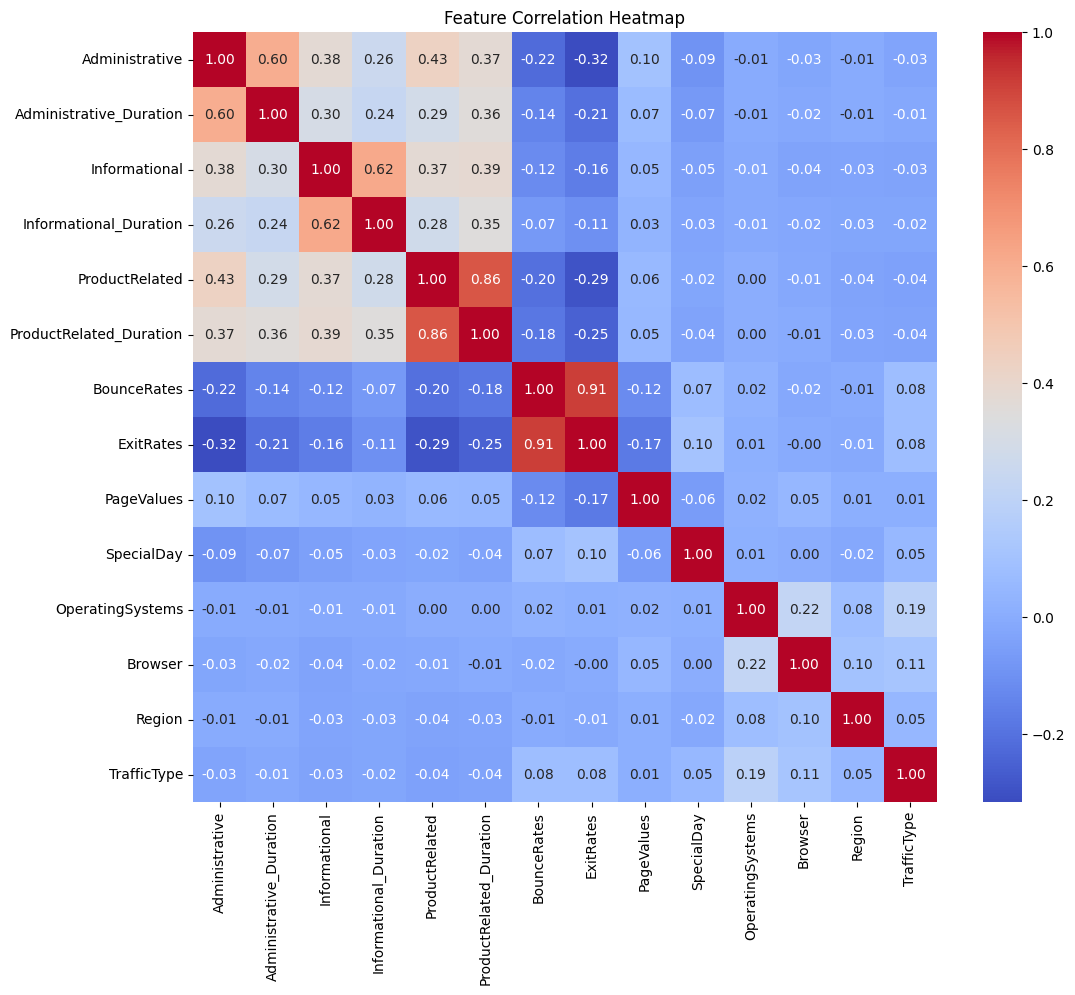

In [ ]:
plt.figure(figsize=(12, 10))
# Calculate correlation only for numerical columns
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### Correlation Interpretation

The heatmap reveals that `BounceRates` and `ExitRates` have a very strong positive correlation (~0.91), indicating that both metrics describe similar user behavior.  

`PageValues` shows a moderate relationship with purchasing behavior, suggesting it may be an important predictor for the machine learning model.


4. Analyze Seasonality (The "Month" Column)
Since e-commerce fluctuates during holidays, visualizing purchases by month is crucial.

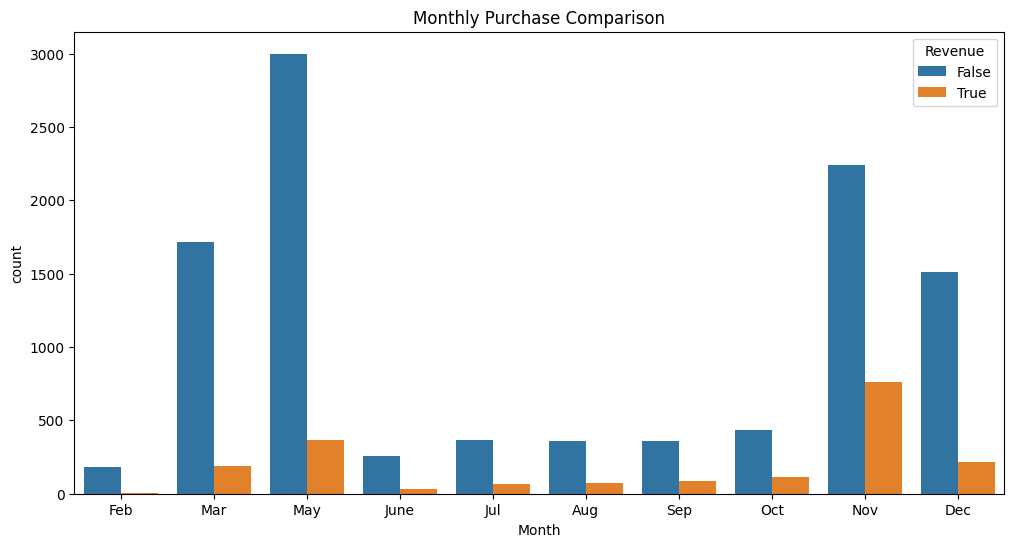

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Month', hue='Revenue', data=df,
              order=['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Purchase Comparison')
plt.show()


4.Visualizing BounceRate Distribution

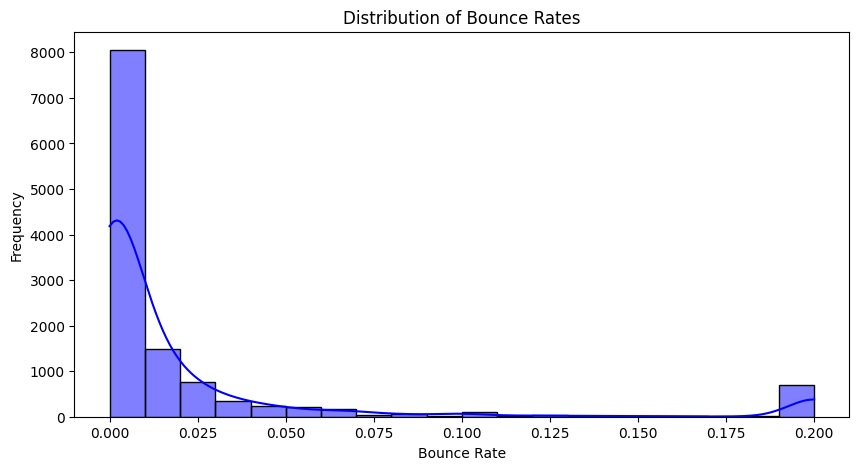

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(df['BounceRates'], bins=20, kde=True, color='blue')
plt.title('Distribution of Bounce Rates')
plt.xlabel('Bounce Rate')
plt.ylabel('Frequency')
plt.show()

5.Comparison of Page Value by Revenue

/tmp/ipykernel_496/2477202359.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Revenue', y='PageValues', data=df, palette='Set1')


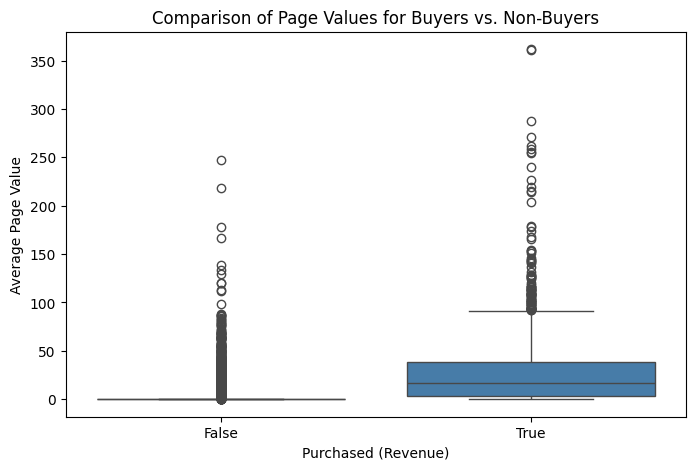

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Comparison 1: PageValues vs. Revenue
plt.figure(figsize=(8, 5))
sns.boxplot(x='Revenue', y='PageValues', data=df, palette='Set1')
plt.title('Comparison of Page Values for Buyers vs. Non-Buyers')
plt.xlabel('Purchased (Revenue)')
plt.ylabel('Average Page Value')
plt.show()


6.Comparison of Bounce Rates by Revenue

/tmp/ipykernel_496/2339432643.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Revenue', y='BounceRates', data=df, palette='Set2')


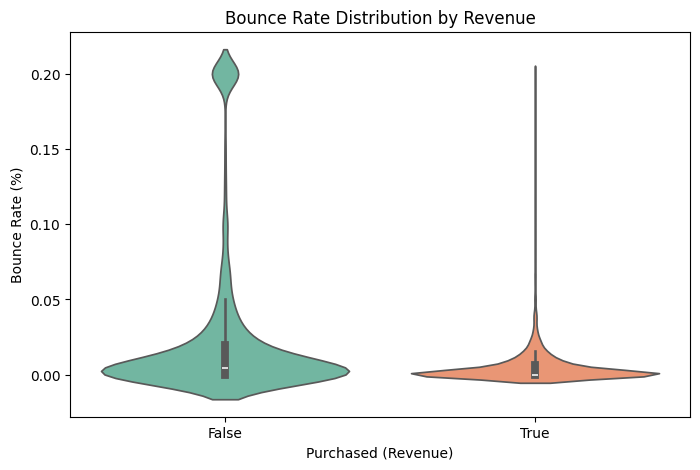

In [ ]:
# Comparison 2: BounceRates vs. Revenue
plt.figure(figsize=(8, 5))
sns.violinplot(x='Revenue', y='BounceRates', data=df, palette='Set2')
plt.title('Bounce Rate Distribution by Revenue')
plt.xlabel('Purchased (Revenue)')
plt.ylabel('Bounce Rate (%)')
plt.show()


### Key Insights

1. **Class Imbalance:** The dataset is highly imbalanced, with most sessions resulting in `Revenue = False`.

2. **Strongest Predictor:** PageValues shows the largest difference between buyers and non-buyers, indicating strong purchase intent.

3. **User Engagement:** High BounceRates are strongly associated with sessions that do not result in purchases.

4. **Seasonality:** Purchase activity varies across months, indicating seasonal trends in online shopping behavior.

## 4. Data Preprocessing & Feature Engineering

Before applying machine learning models, the dataset must be transformed into a format suitable for numerical computation. Machine learning algorithms typically require numerical inputs and consistent feature scales to operate effectively.

In this stage, several preprocessing techniques were applied to convert categorical variables into numerical representations and standardize numerical features. These transformations ensure that the dataset is compatible with machine learning algorithms and that no feature dominates the learning process due to scale differences.

### Preprocessing Pipeline

The following preprocessing steps were applied to prepare the dataset for modeling:

**1. Handling Missing Values**

During the initial inspection stage, the dataset was examined for missing values. No missing values were detected across the features. Therefore, no imputation or value removal was required.

**2. Label Encoding**

Boolean variables such as `Revenue` and `Weekend` were converted from True/False values into numerical form (1/0) using Label Encoding.

Justification: Machine learning algorithms require numerical inputs to compute mathematical operations such as probability estimation and distance calculations.

**3. One-Hot Encoding**

Categorical variables including `Month` and `VisitorType` were transformed into binary dummy variables using one-hot encoding.

Justification: One-hot encoding prevents the model from incorrectly assuming an ordinal relationship between categories (for example, assuming that one month is "greater" than another).

**4. Feature Scaling **

Continuous numerical features were standardized using `StandardScaler`.

Justification: Many machine learning algorithms are sensitive to the scale of input features. Standardization ensures that all numerical features contribute equally during model training.

In [39]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_processed = df.copy()

df_processed.dropna(inplace=True)

le = LabelEncoder()
df_processed['Revenue'] = le.fit_transform(df_processed['Revenue'])
df_processed['Weekend'] = le.fit_transform(df_processed['Weekend'])

categorical_cols = ['Month', 'VisitorType']
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()
numerical_cols = ['Administrative', 'Administrative_Duration', 'Informational',
                  'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                  'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

df_processed[numerical_cols] = scaler.fit_transform(df_processed[numerical_cols])

df_processed.to_csv('preprocessed_data.csv', index=False)

print("Preprocessing is Complete!")
print(f"New dataset shape: {df_processed.shape}")
display(df_processed.head())

Preprocessing is Complete!
New dataset shape: (12330, 27)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,True,False,False,False,False,False,False,False,False,True
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,True,False,False,False,False,False,False,False,False,True
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,True,False,False,False,False,False,False,False,False,True
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,...,True,False,False,False,False,False,False,False,False,True
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,...,True,False,False,False,False,False,False,False,False,True


### Preprocessed Dataset Ready for Modeling

After applying the preprocessing pipeline, the dataset was successfully transformed into a machine-learning-ready format.

All categorical variables have been converted into numerical representations through encoding, and numerical features have been standardized to ensure consistent feature scales. The target variable `Revenue` is now represented as a binary numerical label suitable for classification tasks.

The final processed dataset was exported as `preprocessed_data.csv`, which will be used in the next stage of the project for training and evaluating supervised learning models.


In [40]:
#verification code
df_processed.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  float64
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  float64
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  float64
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

### Key Insights & Challenges

**Key Insights**

- The dataset required minimal cleaning since no missing values were detected.
- Feature encoding was necessary to convert categorical variables into numerical representations suitable for machine learning algorithms.
- Feature scaling ensured that numerical variables operate on comparable scales during model training.

**Challenges**

- The dataset contains a mix of categorical, numerical, and boolean features, which required multiple preprocessing techniques.
- The target variable exhibits class imbalance, with most sessions resulting in no purchase. This imbalance may affect model performance and should be considered during model evaluation.